In [69]:
import cme.decision_models.confidence_accumulation as ca
import numpy as np
import scipy.stats as stats
import pandas as pd
import seaborn as sns
import numpyro as npy
import numpyro.distributions as dist
from cme.utils import common_utils as cu
import jax
import matplotlib.pyplot as plt

np.tile(1,(10,100)).shape

In [70]:
max_samples, max_RT_sec = 2000, 40
#I, J = 5, 100
I, J = 5, 60
n_states, delta, measurement_prob,response_width  = 11, 1, 0.8,2
#n_states, delta, measurement_prob,response_width  = 51, 1, 0.25,5
start_width = (n_states-2*response_width)
start_width


7

In [71]:
drift_rate, diffusion_rate = np.tile(2,(I,1)), np.tile(1,(I,1))
model_type = "Quantum"
transition_type="TIMESTEP"
likelihood_type="SINGLE"
params_type = "NonCentralized"



phi_0 = ca._get_initial_state(n_states, start_width, model_type=model_type, prior_type="Centered")
phi_0

ca.get_intensity_matrix(n_states, drift_rate, diffusion_rate, model_type=model_type)

#from numba import njit

#@njit
def generate_RT(n_states, response_width, delta, measurement_prob, I, J, 
                drift_rate, diffusion_rate, phi_0, max_RT_sec=40, param_sample_id = 1, max_samples=1000,
                model_type="Markov|Quantum", transition_type="RT|TIMESTEP", likelihood_type="SINGLE|JOINT",
                keep_incomplete_transitions=False):
    
    def get_RT_frame(I, mu, sigma):
        
        random_ts = dist.Uniform(delta, max_RT_sec/delta).sample(key=cu.get_rng(), sample_shape=(I,max_samples))
        intensity_matrix = ca.get_intensity_matrix(n_states, mu, sigma, model_type=model_type)
        Mc, Mw, Mn = ca._get_measurement_matrix(n_states, response_width, prob=measurement_prob, model_type = model_type)
        phi_t = ca.perform_state_transition(intensity_matrix=intensity_matrix, RT_s = random_ts, RA_s = None, delta=delta, 
                                            Mc = Mc, Mn = Mn, Mw = Mw, phi_0=phi_0, 
                                            transition_type=transition_type, likelihood_type=likelihood_type)

        states_t = dist.Multinomial(total_count=1, probs=phi_t[...,0]).sample(key=cu.get_rng())
        state_final = np.argwhere(states_t)
        RA = np.select([
                state_final[:,[-1]] < response_width - 1,
                state_final[:,[-1]] >= n_states - response_width - 1
            ], [0,1], default = np.nan)#[:,-1]
        Response = np.hstack((state_final, RA, random_ts.flatten()[:,None]*delta))
        df_res = pd.DataFrame(Response, columns=["part_id", "J", "final_state", "RA", "RT"]).assign(param_sample_id=param_sample_id)
        if not keep_incomplete_transitions:
            df_res = df_res.dropna()
        return df_res
    
    df_sample = []
    df_res = get_RT_frame(I, drift_rate, diffusion_rate)
    
    df_sample.append(df_res)
    get_id = (df_res.groupby(["part_id"]).count() < J)[["J"]].query("J == True").index.values.astype(int)
    counter = 0
    while get_id.size != 0 and counter < 2:
        I = get_id.size
        mu, sigma = drift_rate[get_id,...], diffusion_rate[get_id,...]
        df_res = get_RT_frame(I, mu, sigma)
        df_sample.append(df_res)
        counter += 1
        print(f"Retry: {counter}")

    df_sample = pd.concat(df_sample).groupby(["part_id"]).nth(slice(None, J)).rename(columns={"J":"items"})

    return df_sample

def simulator(drift_rate, diffusion_rate, phi_0):
    n_states, start_width, delta, measurement_prob, max_samples = 51, 11, 0.5, 0.8, 1000
    I, J = drift_rate.shape[0], 20
    model_type="Markov" 
    transition_type="TIMESTEP"
    likelihood_type="SINGLE"

    df_sample = generate_RT(n_states, response_width, delta, measurement_prob, I, J, 
                drift_rate, diffusion_rate, phi_0, max_RT_sec=max_RT_sec, max_samples=max_samples,
                model_type=model_type, transition_type=transition_type, likelihood_type=likelihood_type, 
                keep_incomplete_transitions=False)
    
    return df_sample


generate_RT_jit = jax.jit(generate_RT, static_argnames = ["n_states", "response_width", "delta", "measurement_prob", "I", "J",
                                                        "max_RT_sec", "max_samples",
                                                        "model_type", "transition_type", "likelihood_type", 
                                                        "keep_incomplete_transitions"])

max_samples = 15000
df_sample = []
import itertools as iter
for (ns, rw), prob in iter.product(zip([11, 51, 101], [1, 5, 10]), [0.05]):
    start_width = (n_states-2*response_width)//2
    phi_0 = ca._get_initial_state(n_states, start_width, model_type=model_type, prior_type="Centered")

    df_sample.append(generate_RT(n_states, response_width, delta, measurement_prob, I, J, 
                    drift_rate, diffusion_rate, phi_0, max_RT_sec=max_RT_sec, max_samples=max_samples,
                    model_type=model_type, transition_type=transition_type, likelihood_type="SINGLE", 
                    keep_incomplete_transitions=False).assign(states=ns))
df_sample = pd.concat(df_sample)
df_sample

df_sample.query("RT <= 0")

df_sample.groupby(["part_id"]).count()

sns.displot(df_sample,
x="RT", #hue="part_id", legend=False,
col="states", kind="kde")

In [72]:
import bayesflow as bf
import cme.decision_models.confidence_accumulation as ca

In [73]:
likelihood_type

'SINGLE'

In [74]:
#I, J = 2,20 #batch_size, n_obs

prior_pd_samples = ca.sample_prior_pred_params(n_states=n_states,start_width=start_width, response_width=response_width,
                                                        delta=delta, data_samples=np.zeros((I,J)).shape,
                                                        measurement_prob=measurement_prob, X=np.zeros((I,J)), RT=None, n_samples=1,
                                                        params_type=params_type, model_type=model_type, transition_type=transition_type, 
                                                        likelihood_type=likelihood_type, sampling_type=None, 
                                                    )

In [75]:
prior_fun_jit = jax.jit(ca.sample_prior_pred_params, static_argnames=["n_states","start_width", "response_width",
                                                        "delta", 
                                                        "measurement_prob", "RT", "n_samples",
                                                        "params_type", "model_type", "transition_type", 
                                                        "likelihood_type", "sampling_type"])

In [76]:
key = cu.get_rng()
prior_fun_jit(n_states=n_states,start_width=start_width, response_width=response_width,
                                                        delta=delta, data_samples=None,
                                                        measurement_prob=measurement_prob, X=np.zeros((I,J)), RT=None, n_samples=1,
                                                        params_type=params_type, model_type=model_type, transition_type=transition_type, 
                                                        likelihood_type=likelihood_type, sampling_type=None, key = key
                                                    )

{'diffusion_rate': Array([[[1.],
         [1.],
         [1.],
         [1.],
         [1.]]], dtype=float64),
 'drift_rate': Array([[[-0.81122396],
         [-0.74285503],
         [-0.99958888],
         [-0.73196496],
         [-0.77041707]]], dtype=float64),
 'phi_0': Array([[[[[5.27925721e-01],
           [4.70763812e-01],
           [5.77842385e-02],
           [3.64581888e-02],
           [6.09959690e-02],
           [3.60961547e-01],
           [3.85872301e-01],
           [3.22712296e-13],
           [3.12165459e-01],
           [2.45269104e-01],
           [2.33435779e-01]]],
 
 
         [[[1.87649038e-01],
           [6.23287799e-01],
           [1.21389285e-14],
           [3.29767600e-01],
           [4.11878103e-02],
           [9.45730639e-03],
           [3.08815762e-01],
           [1.20389319e-01],
           [3.53154543e-01],
           [4.13709000e-01],
           [2.45017511e-01]]],
 
 
         [[[2.31222974e-01],
           [4.18242870e-01],
           [2.884011

In [77]:
prior_pd_samples["drift_rate"].shape

(1, 5, 1)

get_RT_jit = jax.jit(ca.get_RT, static_argnames=["n_states", "response_width", "delta", "measurement_prob", 
                                                "data_samples", "param_sample_id",
                                                "model_type", "transition_type", "likelihood_type", 
                                                "sampling_type", "is_test"])

In [78]:
prior_pd_samples["phi_0"][0,...].shape

(5, 1, 11, 1)

In [79]:
df_samples = ca.get_RT(None, n_states, response_width, delta, measurement_prob, np.ones((I,J)), 
        prior_pd_samples["drift_rate"][0,...], prior_pd_samples["diffusion_rate"][0,...], prior_pd_samples["phi_0"][0,...], 
        param_sample_id = -1, model_type = model_type, transition_type = transition_type, 
        likelihood_type = likelihood_type, data_samples = np.ones((I,J)).shape, key = cu.get_rng(),
        sampling_type="GEN")["Samples"]
df_samples.sort_values("final_state", ascending=False).groupby("part_id").count()

,items,final_state,RA,RT,param_sample_id
part_id,,,,,
0.0,60,60,60,60,60
1.0,60,60,60,60,60
2.0,60,60,60,60,60
3.0,60,60,60,60,60
4.0,60,60,60,60,60


In [80]:
PARAM_NAMES = ["v", r"$\sigma$"] + [f"$\phi_{{{s}}}$" for s in range(1,n_states+1)]
PARAM_NAMES

['v',
 '$\\sigma$',
 '$\\phi_{1}$',
 '$\\phi_{2}$',
 '$\\phi_{3}$',
 '$\\phi_{4}$',
 '$\\phi_{5}$',
 '$\\phi_{6}$',
 '$\\phi_{7}$',
 '$\\phi_{8}$',
 '$\\phi_{9}$',
 '$\\phi_{10}$',
 '$\\phi_{11}$']

In [81]:
def prior_fun(batch_size):
    key = cu.get_rng()
    params = prior_fun_jit(n_states=n_states,start_width=start_width, response_width=response_width,
                            delta=delta, data_samples=None,
                            measurement_prob=measurement_prob, X=np.zeros((batch_size,J)), RT=None, n_samples=1,
                            params_type=params_type, model_type=model_type, transition_type=transition_type, 
                            likelihood_type=likelihood_type, sampling_type=None, key=key
                            )
    
    return np.hstack((params["drift_rate"][0,...], params["diffusion_rate"][0,...], params["phi_0"].squeeze()))

prior = bf.simulation.Prior(batch_prior_fun=prior_fun, param_names=PARAM_NAMES)
params = prior(batch_size=I)
params

{'prior_draws': array([[ 1.16151420e+00,  1.00000000e+00,  6.20377970e-02,
          3.10377195e-01,  2.05663121e-02,  7.09078929e-01,
          4.89809756e-06,  5.76858581e-02,  2.72216937e-01,
          2.87252601e-01,  5.14182812e-09,  2.51109965e-03,
          4.86468217e-01],
        [ 2.36158465e+00,  1.00000000e+00,  2.60245036e-01,
          7.69047111e-15,  8.61880858e-02,  6.84475801e-10,
          1.88947652e-01,  3.51009625e-01,  3.17680614e-01,
          1.59529648e-01,  2.11761625e-01,  2.97486478e-01,
          7.11493705e-01],
        [ 2.00370222e+00,  1.00000000e+00,  4.75265782e-01,
          1.89216524e-01,  1.09657122e-01,  3.58892291e-01,
          3.24642562e-01,  5.71423529e-01,  1.97864807e-01,
          2.78861270e-02,  2.82627566e-01,  2.13869007e-01,
          5.20855243e-03],
        [-3.56995487e-01,  1.00000000e+00,  4.37447142e-01,
          6.39835271e-09,  1.09117809e-02,  5.69175460e-02,
          1.66587001e-01,  6.79196081e-03,  1.95004740e-01,
    

f = prior.plot_prior2d(n_samples=10)

In [82]:
params["prior_draws"][:,2:][None,:,None].shape

(1, 5, 1, 11)

In [83]:
def likelihood_fun(params, n_obs=J):
    drift_rate = params[:,[0]]#[:,None]
    diffusion_rate = params[:,[1]]#[:,None]
    phi_0 = params[:,2:][:,None,:,None]

    batch_size = drift_rate.shape[0]

    df_samples = ca.get_RT(None, n_states, response_width, delta, measurement_prob, np.ones((batch_size,n_obs)), 
        drift_rate, diffusion_rate, phi_0, 
        param_sample_id = -1, model_type = model_type, transition_type = transition_type, 
        likelihood_type = likelihood_type, data_samples = np.ones((batch_size,n_obs)).shape, key = cu.get_rng(),
        sampling_type="GEN")["Samples"]

    return np.vstack((df_samples.RT.values.reshape(-1, n_obs)[None,...], df_samples.RA.values.reshape(-1, n_obs)[None,...])).transpose((1,2,0))

#Response = likelihood_fun(params["prior_draws"], I, J)

In [84]:
Response.shape

(5, 60, 2)

In [85]:
context_gen = bf.simulation.ContextGenerator(
    #non_batchable_context_fun= lambda: J, # Number of trials.. J can change randomly to accomodate missing data
    #use_non_batchable_for_batchable=True,
)

In [86]:
simulator = bf.simulation.Simulator(batch_simulator_fun=likelihood_fun, context_generator=context_gen)

In [87]:
simulator(params["prior_draws"])

{'sim_data': array([[[30.22824147,  0.        ],
         [50.95089424,  0.        ],
         [30.12292357,  0.        ],
         [39.22733488,  0.        ],
         [14.53889843,  0.        ],
         [42.92314032,  0.        ],
         [ 4.81200102,  0.        ],
         [49.47303816,  0.        ],
         [39.13194591,  0.        ],
         [ 5.58197735,  0.        ],
         [28.61496034,  0.        ],
         [36.27504862,  0.        ],
         [23.3396758 ,  0.        ],
         [15.34180798,  0.        ],
         [39.92884883,  0.        ],
         [ 2.29912059,  0.        ],
         [42.25117184,  0.        ],
         [ 2.3200255 ,  0.        ],
         [34.62834457,  0.        ],
         [38.13694583,  0.        ],
         [16.70456521,  0.        ],
         [31.19244634,  0.        ],
         [49.7453519 ,  0.        ],
         [ 3.42507114,  0.        ],
         [35.98599546,  0.        ],
         [26.02927976,  0.        ],
         [ 1.06019126,  1.

In [88]:
model = bf.simulation.GenerativeModel(prior=prior, simulator=simulator, name=model_type,
                                       prior_is_batched=True, simulator_is_batched=True)

INFO:root:Performing 2 pilot runs with the Quantum model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 13)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 60, 2)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.


In [89]:
example_sim = model(batch_size=10)
print(list(example_sim.keys()))

['prior_non_batchable_context', 'prior_batchable_context', 'prior_draws', 'sim_non_batchable_context', 'sim_batchable_context', 'sim_data']


In [90]:
print("Shape of sim_data: ", example_sim["sim_data"].shape)

Shape of sim_data:  (10, 60, 2)


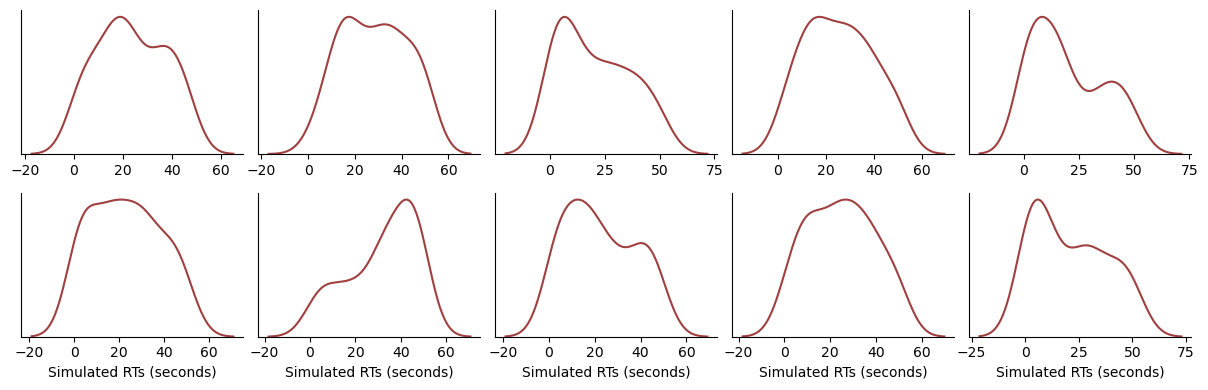

In [91]:
f, axarr = plt.subplots(2, 5, figsize=(12, 4))
for i, ax in enumerate(axarr.flat):
    sns.kdeplot(example_sim["sim_data"][i, :, 0].flatten(), color="maroon", alpha=0.75, ax=ax)
    sns.despine(ax=ax)
    ax.set_ylabel("")
    ax.set_yticks([])
    if i > 4:
        ax.set_xlabel("Simulated RTs (seconds)")
f.tight_layout()

In [92]:
summary_net = bf.networks.SetTransformer(input_dim=2, summary_dim=32, name=f"{model_type}_summary")
#test_inp = model(batch_size=2)
#summary_rep = summary_net(test_inp["sim_data"]).numpy()

#print("Shape of simulated data sets: ", test_inp["sim_data"].shape)
#print("Shape of summary vectors: ", summary_rep.shape)

In [93]:
inference_net = bf.networks.InvertibleNetwork(
    num_params=len(prior.param_names),
    coupling_settings={"dense_args": dict(kernel_regularizer=None), "dropout": False},
    name=f"{model_type}_inference",
)

In [94]:
amortizer = bf.amortizers.AmortizedPosterior(inference_net, summary_net, name=f"{model_type}_amortizer")

In [95]:
prior_means, prior_stds = prior.estimate_means_and_stds(n_draws=100000)
prior_means = np.round(prior_means, decimals=1)
prior_stds = np.round(prior_stds, decimals=1)

In [96]:
prior_stds

array([[0.3, 0. , 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2]])

In [97]:
def configurator(forward_dict):
    """Configure the output of the GenerativeModel for a BayesFlow setup."""

    # Prepare placeholder dict
    out_dict = {}

    # Extract simulated response times
    data = forward_dict["sim_data"]

    # Concatenate rt, resp, context
    out_dict["summary_conditions"] = data

    # Get data generating parameters
    params = forward_dict["prior_draws"]#.astype(np.float32)

    # Standardize parameters
    out_dict["parameters"] = params #np.where(prior_stds, ((params - prior_means) / prior_stds), params)

    return out_dict

In [98]:
trainer = bf.trainers.Trainer(
    generative_model=model, amortizer=amortizer, configurator=configurator, checkpoint_path=f"{model_type}3_model"
)

INFO:root:Loaded loss history from Quantum3_model/history_60.pkl.
INFO:root:Networks loaded from Quantum3_model/ckpt-60
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


In [99]:
amortizer.summary()

Model: "Quantum_amortizer"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Quantum_inference (Inverti  multiple                  538068    
 bleNetwork)                                                     
                                                                 
 Quantum_summary (SetTransf  multiple                  55312     
 ormer)                                                          
                                                                 
Total params: 593380 (2.26 MB)
Trainable params: 593224 (2.26 MB)
Non-trainable params: 156 (624.00 Byte)
_________________________________________________________________


In [100]:
%%time
_ = model(2) # expected time less than a sec

CPU times: user 3.35 s, sys: 6.79 ms, total: 3.36 s
Wall time: 3.25 s


In [101]:
%%time
sim_data = model(40)

CPU times: user 1min 7s, sys: 1.44 s, total: 1min 8s
Wall time: 1min 6s


In [102]:
sim_data["prior_draws"].shape, sim_data["sim_data"].shape

((40, 13), (40, 60, 2))

In [103]:
#history = trainer.train_online(epochs=60, iterations_per_epoch=500, batch_size=100)
history = trainer.train_rounds(rounds=500, sim_per_round=40, epochs=60, batch_size=100, validation_sims=100)
#history = trainer.train_offline(sim_data, epochs=60, batch_size=10)

INFO:root:Generated 100 simulations for validation.
INFO:root:Simulating initial 40 data sets for training...


Training epoch 1:   0%|          | 0/1 [00:00<?, ?it/s]

INFO:root:Validation, Epoch: 1, Loss: 3.768


Training epoch 2:   0%|          | 0/1 [00:00<?, ?it/s]

INFO:root:Validation, Epoch: 2, Loss: 1.756


...

INFO:root:Validation, Epoch: 58, Loss: 0.011


Training epoch 59:   0%|          | 0/1 [00:00<?, ?it/s]

INFO:root:Validation, Epoch: 59, Loss: -1.061


Training epoch 60:   0%|          | 0/1 [00:00<?, ?it/s]

INFO:root:Validation, Epoch: 60, Loss: -0.793
/home/axon/rkm160630/.conda/envs/ds/lib/python3.11/site-packages/bayesflow/helper_classes.py:683: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  losses_list = pd.concat(losses_list, axis=0).value.to_list()
INFO:root:Simulating new 40 data sets and appending to previous...
INFO:root:New total number of simulated data sets for training: 120
